
## (25, 'o_co_util') model for PDF shaping (n samples)

This uses the new object oriented class for PDF shaping.

* (25, 'o_co_util') ...... i_h2i_rate, i_h2_temp, i_ng_rate, i_ng_temp, i_pci_rate, i_wpi_rate, i_sgi_rate, i_sgi_COH2ratio, i_sgi_ReProRatio, i_o2_volfract, i_hbtemp, i_wind_rt, i_blast_H2O, i_bdn_H2O

## Web applicationi inputs and 1 outputs

Run interactively on the web at: https://rcalix1.github.io/ProbabilityDensityFunctionsFromNeuralNets/experiments/2023/july2023/XGBoost/deployment/tuyere/




## Inputs


(2, 'i_h2i_rate').........i_h2i_rate

(3, 'i_pci_rate').........i_pci_rate

(4, 'i_wpi_rate').........i_wpi_rate

(5, 'i_ngi_rate').........i_ng_rate

(6, 'i_o2_volfract').......i_o2_volfract

(7, 'i_ng_temp')...........i_ng_temp

(8, 'i_h2_temp')...........i_h2_temp

(9, 'i_hbtemp')............i_hbtemp

(10, 'i_wind_rt')..........i_wind_rt

(11, 'i_blastH2O').........i_blast_H2O

(12, 'i_BdnH2O')............i_bdn_H2O

(13, 'i_sgi_rate').........i_sgi_rate

(15, 'i_sgi_COH2ratio').....i_sgi_COH2ratio

(16, 'i_sgi_ReProRatio')....i_sgi_ReProRatio


  

## Outputs



(25, 'o_co_util')





## Installs


In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime



## Imports


In [2]:

import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)




In [4]:

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt



In [5]:

import PDFshapingUtils as PDF_tk



## Instantiate PDF shaping and regression class


In [6]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()



## Initialize parameters


In [7]:

PDFshapingOBJ.N_error_range = 5         ## 20
PDFshapingOBJ.mean_impulse  = 0.0       ## -7.0      ## 0.0
PDFshapingOBJ.std_impulse   = 0.001     ## 1.0
PDFshapingOBJ.kde_std       = 0.5       ## 0.1       ## 0.5      ## 3.0  ## smaller is better approximation?
PDFshapingOBJ.bandwidth     = 0.2       ## 0.2->more jagged, 2.0->more smooth


In [8]:

PDFshapingOBJ.initializeImpulseGaussian()



## Run checks


In [9]:

## print(PDFshapingOBJ.x_range_impulse_func )
## print(PDFshapingOBJ.impulse_func_vector_vals )
## print(PDFshapingOBJ.quadratic_weights)
print(PDFshapingOBJ.x_range_impulse_func.shape )
print(PDFshapingOBJ.impulse_func_vector_vals.shape )
print(PDFshapingOBJ.quadratic_weights.shape)
 
print( sum(PDFshapingOBJ.impulse_func_vector_vals) )      ## should add up to 100 (i.e. 1.0 prob density)


torch.Size([1000])
torch.Size([1000])
torch.Size([1000])
tensor(100.0000)


In [10]:

## plt.plot(PDFshapingOBJ.x_range_impulse_func, PDFshapingOBJ.impulse_func_vector_vals)
## plt.show()



## RUN KDE test


In [11]:

## PDFshapingOBJ.test_torchKDE_with_fake_data()



## Load Data


In [12]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [13]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,0,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [14]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

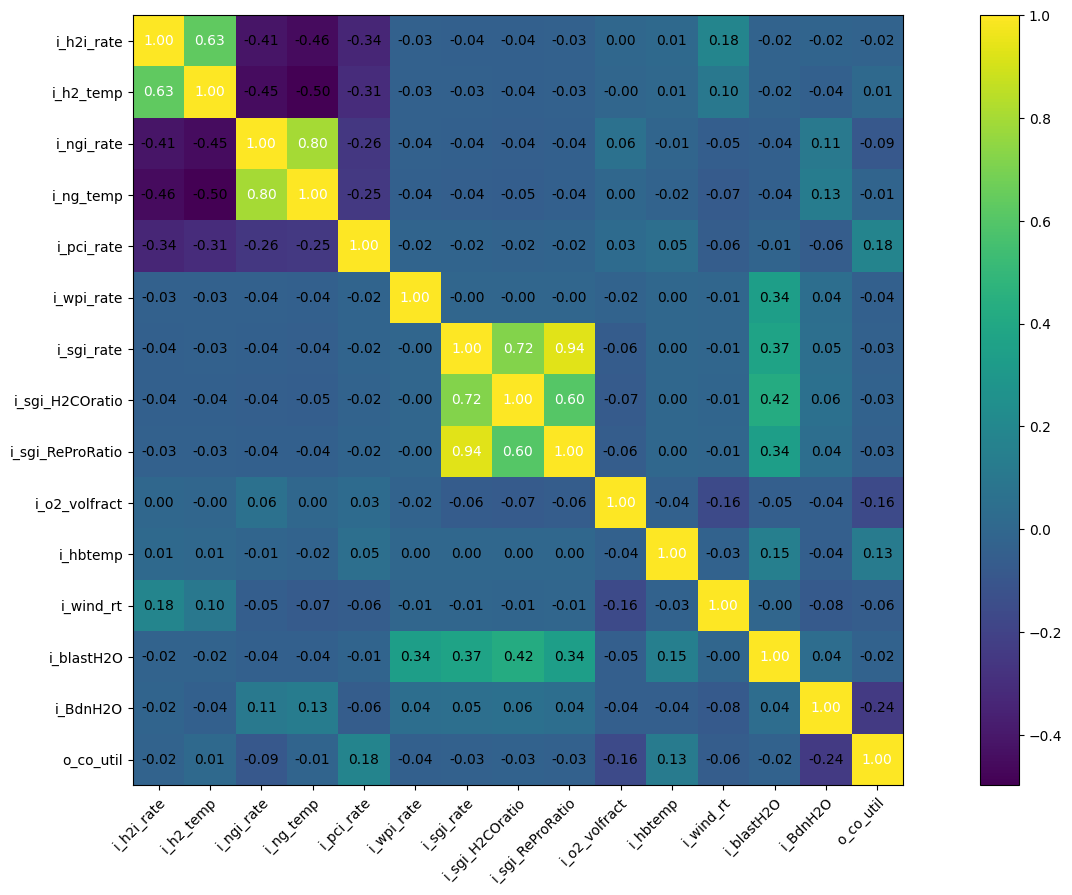

In [15]:




PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_sgi_rate','i_sgi_H2COratio','i_sgi_ReProRatio','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','i_blastH2O','i_BdnH2O', 'o_co_util' ]

ONNX_name = 'o_co_util'


PDFshapingOBJ.print_correlation_coefficients()


In [16]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)



## Select inputs and outputs


In [17]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [ 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16 ] , 
                   outputs= [ 25 ]   
)






14
1


In [18]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 14)
(4999, 1)


In [19]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [20]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 14)
(1000, 14)
(3999, 1)
(1000, 1)


In [21]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [22]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [23]:

PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## NN architectures


In [24]:

#######################################################
## Linear Regression

class LinRegNet_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 1) 
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)

    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        y_scaled = self.linear1(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled

    
#############################################################
## Multi-Layer Perceptron

class MLP_Net_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
    
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        
        y_scaled = self.linear2(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

#############################################################
## Deep Learning model with 2 hidden layers


class DL_Net_SIO(nn.Module):
    
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 6)
        self.act2    = nn.Sigmoid() 
        self.linear3 = nn.Linear(6, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
        
        ## nn.init.xavier_uniform_(self.linear3.weight)
        ## nn.init.zeros_(self.linear3.bias)
    
    ## perform inference
    def forward(self, x):
        
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.act2(x)
        x = self.dropout(x)
        
        y_scaled = self.linear3(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled


In [25]:

#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        ## F1
        self.f1_linear1 = nn.Linear(14, 1)       
        
        ## F2
        self.f2_linear1 = nn.Linear(14, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, 1)       
        self.f2_dropout = nn.Dropout(0.25)
        
        
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    



## Results for g(x) = F1(x) + F2(x) with No PDF shaping

F1 = Linear

F2 = Nonlinear


In [26]:

def fit_y_scaled(num_epochs, model, loss_fn, opt):
    
    PDFshapingOBJ.list_metric = []
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
            
            
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(
            torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()   )
            )
        )
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,           PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy()  ))
    


In [27]:

PDFshapingOBJ.the_string           = "No_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name


0  loss=  tensor(0.7567, grad_fn=<MseLossBackward0>)
200  loss=  tensor(0.5511, grad_fn=<MseLossBackward0>)
400  loss=  tensor(0.9387, grad_fn=<MseLossBackward0>)
600  loss=  tensor(0.1573, grad_fn=<MseLossBackward0>)
800  loss=  tensor(0.2605, grad_fn=<MseLossBackward0>)
1000  loss=  tensor(0.0730, grad_fn=<MseLossBackward0>)
1200  loss=  tensor(2.7732, grad_fn=<MseLossBackward0>)
1400  loss=  tensor(0.1813, grad_fn=<MseLossBackward0>)
1600  loss=  tensor(0.2457, grad_fn=<MseLossBackward0>)
1800  loss=  tensor(0.4881, grad_fn=<MseLossBackward0>)


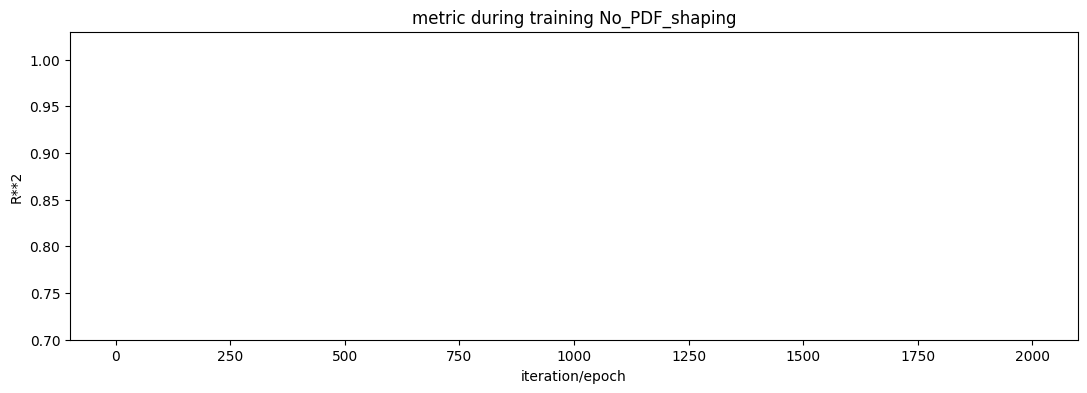

Training loss: tensor(0.3710, grad_fn=<MseLossBackward0>)
Training R**2: 0.4205892430014738
Test loss - scaled: tensor(0.3574, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(2.8001, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.5473673768694411
Testing R**2 - descaled: 0.547367340874408
*****
*****
Testing R**2 - Output: 0 o_co_util 0.547367340874408


In [28]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)

opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate   )
loss_fn = F.mse_loss


fit_y_scaled(PDFshapingOBJ.N_EPOCHS, model, loss_fn, opt)


pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,         PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,       PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))

PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [29]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(52.297752, 52.9)
**************************************************
preds, real
(51.51176, 53.6)
**************************************************
preds, real
(47.219997, 45.6)
**************************************************
preds, real
(53.255768, 48.2)
**************************************************
preds, real
(48.479877, 47.0)
**************************************************
preds, real
(52.040154, 51.4)
**************************************************
preds, real
(50.253338, 51.0)
**************************************************
preds, real
(52.709633, 50.8)
**************************************************
preds, real
(51.4971, 53.9)
**************************************************
preds, real
(50.8612, 50.9)
**************************************************
preds, real
(50.2454, 48.9)
**************************************************
preds, real
(52.187897, 54.7)
***********************************

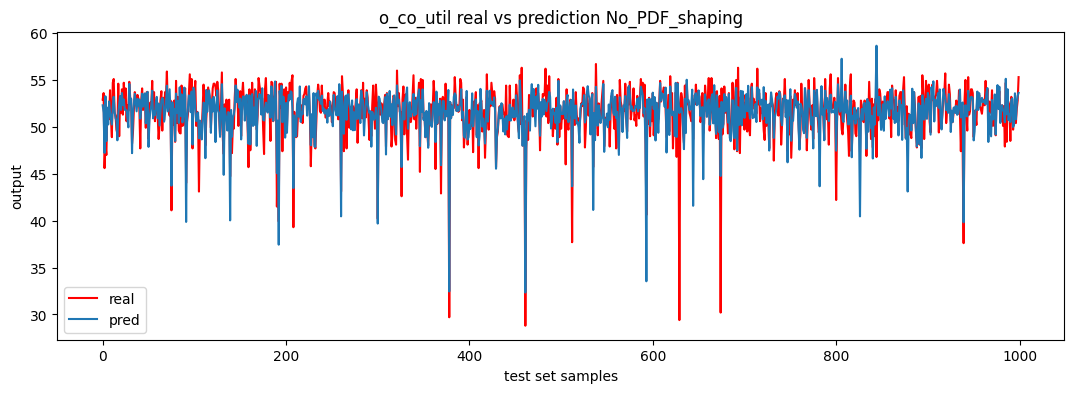

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


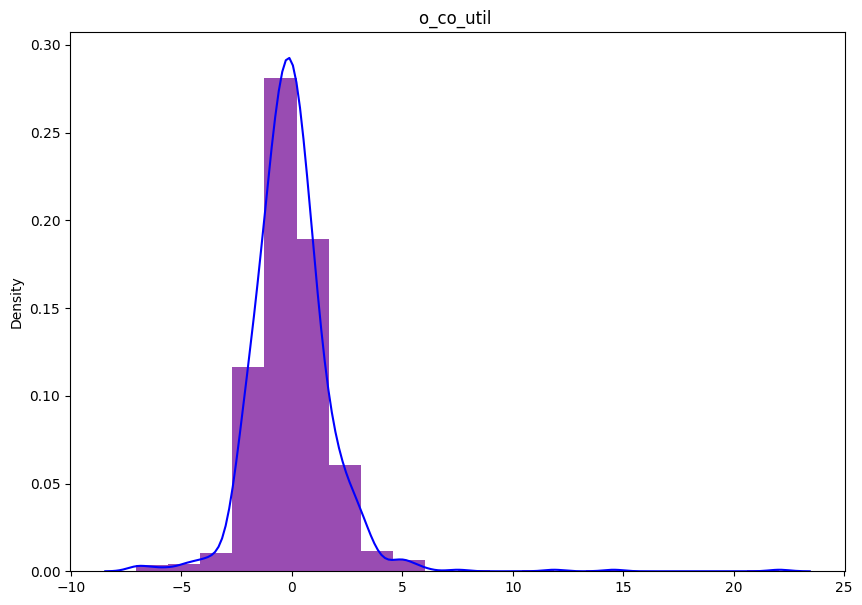

In [30]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


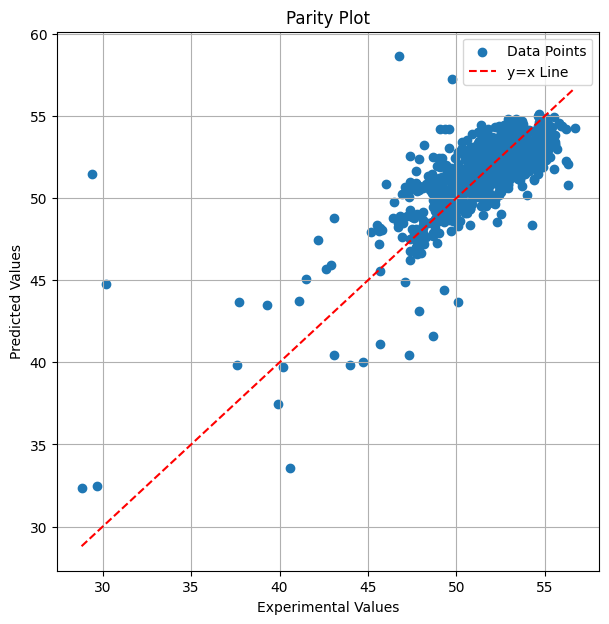

In [31]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## Export ONNX model


In [32]:


name_to_use_onnx = "ONNXmodels/F1plusF2NNs_" + ONNX_name + ".onnx"

model.eval()

dummy_input = torch.randn(1, 14)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  name_to_use_onnx, 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)




## To compare NNs to XGBoost


In [33]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [34]:

pred_descaled


tensor([[52.0888],
        [51.4103],
        [47.7813],
        [52.9944],
        [47.5946],
        [51.8115],
        [50.8967],
        [52.6998],
        [52.2426],
        [51.1893],
        [50.2543],
        [52.5526],
        [53.0381],
        [51.4717],
        [50.8004],
        [50.7188],
        [49.2176],
        [52.2547],
        [52.3923],
        [52.7908],
        [51.4257],
        [53.2726],
        [52.0036],
        [52.3881],
        [51.8474],
        [52.3237],
        [50.2973],
        [51.7377],
        [50.4425],
        [54.1725],
        [53.1481],
        [52.5433],
        [48.7006],
        [51.7541],
        [51.9709],
        [53.3534],
        [53.5813],
        [51.3451],
        [52.7584],
        [52.0713],
        [52.6589],
        [50.9185],
        [52.1467],
        [53.8111],
        [52.0179],
        [53.1392],
        [53.2281],
        [50.4539],
        [53.3639],
        [53.1085],
        [48.7207],
        [51.1780],
        [51.

In [35]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.5433166070935374
Testing R**2 - descaled: 0.543316602927432



## Results for g(x) = F1(x) + F2(x) with PDF shaping

F1 = Linear

F2 = Nonlinear


In [36]:

def fit_y_scaled_PDF(num_epochs, num_epochs_pdf, model, loss_fn, opt, kl_loss, scheduler):
    
    PDFshapingOBJ.list_metric = []
      
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(r2_avg.detach().numpy())
        
        
    opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol  )    
        
    for epoch in range(num_epochs_pdf):
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
       
        error =   pred_scaled.float() - PDFshapingOBJ.y_train_tr_scaled.float()          ## 715  x 1
        
        basisFunc = PDFshapingOBJ.train_multiple_kernels_per_output( error )             ## 1000 x 1
        
        p_pred = basisFunc.float() 
        q_real = PDFshapingOBJ.impulse_func_vector_vals.unsqueeze(1).float() 
        
        
        diff = ( p_pred - q_real )**2              ## 1000 x 1
        diff = diff * PDFshapingOBJ.quadratic_weights.unsqueeze(1)      
          
        
        loss = torch.mean( diff  ) 
        

        ## loss_diff = loss_fn(p_pred, q_real)
        ## input_kl  = F.log_softmax(p_pred, dim=0) # F.log_softmax(p_kl)
        ## target_kl = F.softmax(    q_real, dim=0) # F.softmax(q_kl)
        ## loss =  loss_diff   ## kl_loss(input_kl, target_kl)  ##   +  torch.std(p_pred)
        
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
      
        
        ## PDFshapingOBJ.updateImpulseGaussian_with_new_standard_deviation(decay_impulse_std )
        

        ## print(epoch, " loss= ", loss)
        if epoch % 5000 == 0:
            print(epoch, " loss= ", loss)
            print(PDFshapingOBJ.impulse_func_vector_vals.shape )
            print(PDFshapingOBJ.quadratic_weights.shape)
            print(error.shape)
            print(basisFunc.shape)
            ##### PDFshapingOBJ.print_errors_kdes(  error, basisFunc )
            print(PDFshapingOBJ.impulse_func_vector_vals.shape)
            print('Epoch-{0} lr: {1}'.format(epoch, opt.param_groups[0]['lr']))
      

        r2_avg = torch.mean(torch.tensor(
                 r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
        
        
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,       PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy() ))
    


In [37]:

PDFshapingOBJ.the_string           = "With_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name

PDFshapingOBJ.learning_rate_pdfcontrol  = 0.001       ## 0.001
PDFshapingOBJ.N_EPOCHS_PDF              = 5000
PDFshapingOBJ.N_EPOCHS                  = 0

decay_impulse_std                       = PDFshapingOBJ.std_impulse / PDFshapingOBJ.N_EPOCHS_PDF 


1666
0  loss=  tensor(0.0260, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3999, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-0 lr: 0.001


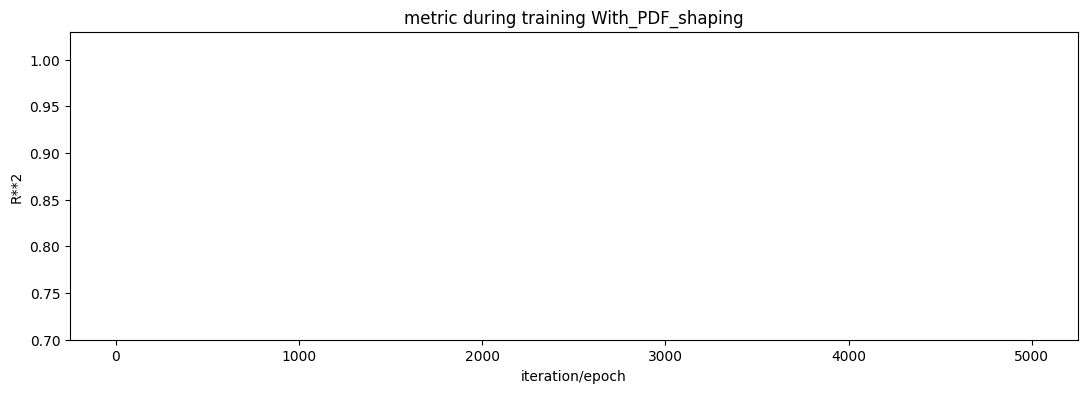

Training loss: tensor(1.6386, grad_fn=<MseLossBackward0>)
Training R**2: -0.7182885028328392
Test loss - scaled: tensor(3.0601, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(23.9750, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: -0.256614803759442
Testing R**2 - descaled: -0.2566149471546766
*****
*****
Testing R**2 - Output: 0 o_co_util -0.2566149471546766


In [38]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)



opt         = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol    )


step_size_scheduler = int(PDFshapingOBJ.N_EPOCHS_PDF / 3)
print(step_size_scheduler)
                          
scheduler   = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.1)



loss_fn      = F.mse_loss
kl_loss      = nn.KLDivLoss(reduction="batchmean")
loss_softmax = F.binary_cross_entropy


fit_y_scaled_PDF(PDFshapingOBJ.N_EPOCHS, PDFshapingOBJ.N_EPOCHS_PDF, model, loss_fn, opt, kl_loss, scheduler)

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,       PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,     PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:',   r2_score( pred_scaled.detach().numpy(),PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()   ))


PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [39]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(52.615078, 52.9)
**************************************************
preds, real
(53.845985, 53.6)
**************************************************
preds, real
(48.446148, 45.6)
**************************************************
preds, real
(54.05229, 48.2)
**************************************************
preds, real
(52.329567, 47.0)
**************************************************
preds, real
(51.80948, 51.4)
**************************************************
preds, real
(50.365894, 51.0)
**************************************************
preds, real
(55.52957, 50.8)
**************************************************
preds, real
(52.66956, 53.9)
**************************************************
preds, real
(51.693035, 50.9)
**************************************************
preds, real
(49.291, 48.9)
**************************************************
preds, real
(53.38997, 54.7)
************************************

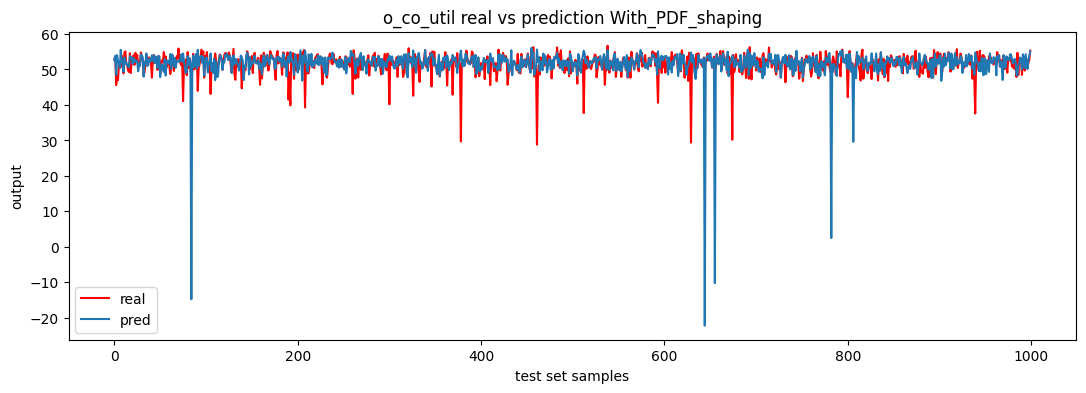

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


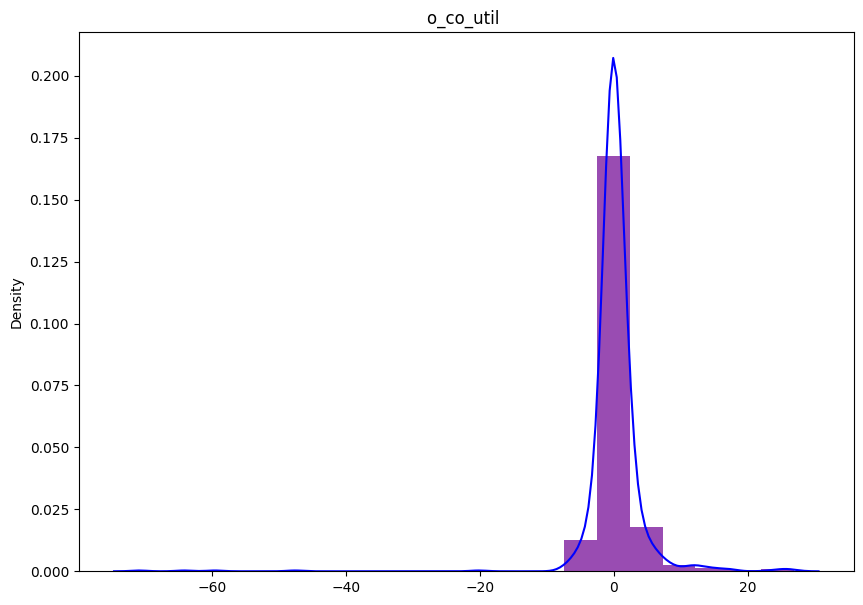

In [40]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


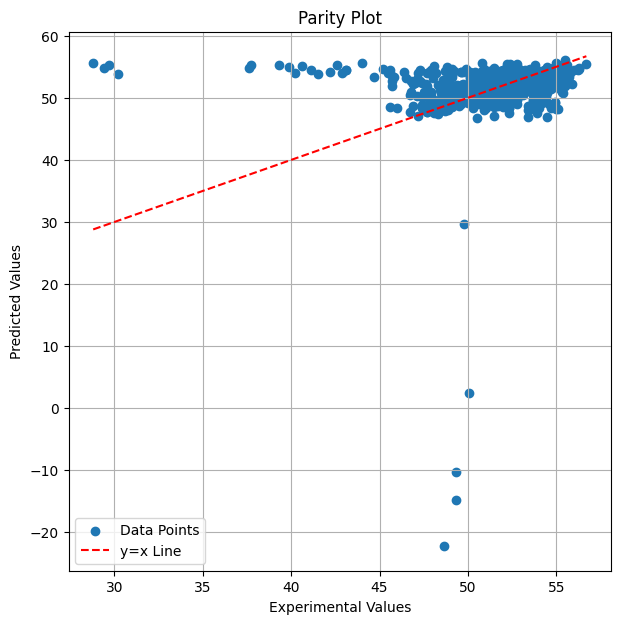

In [41]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## To compare to NNs to XGBoost


In [42]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [43]:

## y_pred

pred_descaled


tensor([[ 52.2381],
        [ 53.4837],
        [ 48.6375],
        [ 52.7714],
        [ 51.2417],
        [ 51.5778],
        [ 50.3804],
        [ 55.0127],
        [ 53.4693],
        [ 51.5312],
        [ 51.0902],
        [ 53.1420],
        [ 51.1182],
        [ 51.9354],
        [ 51.2522],
        [ 50.7410],
        [ 49.1573],
        [ 53.7735],
        [ 53.5916],
        [ 53.2463],
        [ 51.5055],
        [ 53.1131],
        [ 52.1861],
        [ 52.1256],
        [ 52.2003],
        [ 52.7188],
        [ 47.8926],
        [ 51.4782],
        [ 51.1244],
        [ 55.8696],
        [ 53.9898],
        [ 53.6150],
        [ 50.8609],
        [ 52.5623],
        [ 53.8037],
        [ 52.1284],
        [ 51.5724],
        [ 51.1381],
        [ 53.0148],
        [ 53.7093],
        [ 52.0879],
        [ 53.7371],
        [ 51.5673],
        [ 53.9916],
        [ 51.7558],
        [ 53.2505],
        [ 53.2123],
        [ 50.4325],
        [ 53.8364],
        [ 53.2918],


In [44]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: -0.24979961351068303
Testing R**2 - descaled: -0.24979959110830907



## Export ONNX model


In [45]:

'''

model.eval()

dummy_input = torch.randn(1, 6)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)

'''


'\n\nmodel.eval()\n\ndummy_input = torch.randn(1, 6)\n\n\ninput_names = ["input1"]\noutput_names = ["output1", "output2"]\n\ntorch.onnx.export(\n  model, \n  dummy_input, \n  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", \n  verbose=False, \n  input_names  = input_names,\n  output_names = output_names\n)\n\n'


## XGBoost


In [46]:

regressor = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [47]:

regressor.fit(PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [48]:

print( len(PDFshapingOBJ.X_train  ))
print( len(PDFshapingOBJ.y_train  ))
  


3999
3999


In [49]:

## columns_thing = ['i_h2_inj_kg_thm', 'i_pul_coal_inj_kg_thm', 'i_nat_gas_inj_kg_thm', 'i_nat_gas_t_k', 
##                  'i_o2_vol_perce', 'i_hot_blast_temp_k', ]



## pd.DataFrame(regressor.feature_importances_.reshape(1, -1), columns=columns_thing)


In [50]:

y_pred = regressor.predict(PDFshapingOBJ.X_test )


In [51]:

y_pred


array([52.000565, 51.90557 , 48.37835 , 52.593655, 48.473335, 51.98291 ,
       51.76053 , 49.38778 , 52.37283 , 51.767784, 50.277824, 53.556923,
       55.118526, 52.797848, 50.94952 , 51.42021 , 48.49707 , 54.364277,
       50.228954, 53.608425, 52.290108, 52.541275, 51.62315 , 53.928436,
       51.898537, 53.629   , 49.888405, 52.088394, 49.74295 , 53.473495,
       53.463646, 52.445126, 48.50136 , 51.849957, 52.4456  , 54.129192,
       54.15316 , 52.554806, 53.409855, 52.09886 , 54.487076, 50.309235,
       51.380558, 52.793003, 51.857624, 53.52251 , 53.67347 , 50.290573,
       53.7518  , 53.144886, 47.839035, 51.131523, 51.84009 , 54.23962 ,
       53.686985, 49.991287, 53.896103, 53.753742, 53.29695 , 52.3407  ,
       52.31313 , 47.513527, 50.07275 , 50.82661 , 52.530357, 52.78163 ,
       53.20241 , 50.58664 , 52.963776, 52.902023, 54.01858 , 51.367   ,
       52.933174, 53.383858, 54.35208 , 45.994766, 52.5692  , 50.2756  ,
       54.280247, 49.385715, 53.872715, 50.963215, 

In [52]:

mean_squared_error(PDFshapingOBJ.y_test , y_pred)


2.0564063

In [53]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.7397374601413422

In [54]:

len(y_pred) 


1000

In [55]:

list_preds = []
list_reals = []

print( "preds, real"   )
  
for j in range(   len(y_pred)    ):
    print(   y_pred[j], PDFshapingOBJ.y_test[j][0]   )
    
    list_preds.append(   y_pred[j]   )
    list_reals.append(  PDFshapingOBJ.y_test[j][0]   )


preds, real
52.000565 52.9
51.90557 53.6
48.37835 45.6
52.593655 48.2
48.473335 47.0
51.98291 51.4
51.76053 51.0
49.38778 50.8
52.37283 53.9
51.767784 50.9
50.277824 48.9
53.556923 54.7
55.118526 55.1
52.797848 51.5
50.94952 51.2
51.42021 49.7
48.49707 49.3
54.364277 54.6
50.228954 49.0
53.608425 53.2
52.290108 51.5
52.541275 54.0
51.62315 51.3
53.928436 54.7
51.898537 52.8
53.629 54.1
49.888405 50.6
52.088394 52.3
49.74295 51.7
53.473495 54.8
53.463646 53.1
52.445126 52.9
48.50136 48.2
51.849957 49.4
52.4456 51.8
54.129192 53.7
54.15316 53.2
52.554806 52.8
53.409855 53.4
52.09886 53.0
54.487076 51.9
50.309235 47.7
51.380558 52.8
52.793003 54.1
51.857624 51.8
53.52251 53.4
53.67347 53.4
50.290573 49.9
53.7518 53.7
53.144886 53.7
47.839035 48.7
51.131523 51.7
51.84009 52.6
54.23962 52.2
53.686985 54.9
49.991287 51.4
53.896103 53.7
53.753742 50.6
53.29695 52.4
52.3407 52.2
52.31313 51.1
47.513527 48.7
50.07275 50.2
50.82661 52.8
52.530357 53.8
52.78163 49.6
53.20241 53.1
50.58664 50.7
52

In [56]:

len( list_preds )


1000

In [57]:

len( list_reals )


1000

In [58]:

PDFshapingOBJ.the_string           = "XGBoost"
PDFshapingOBJ.furnace_model_name   = ONNX_name


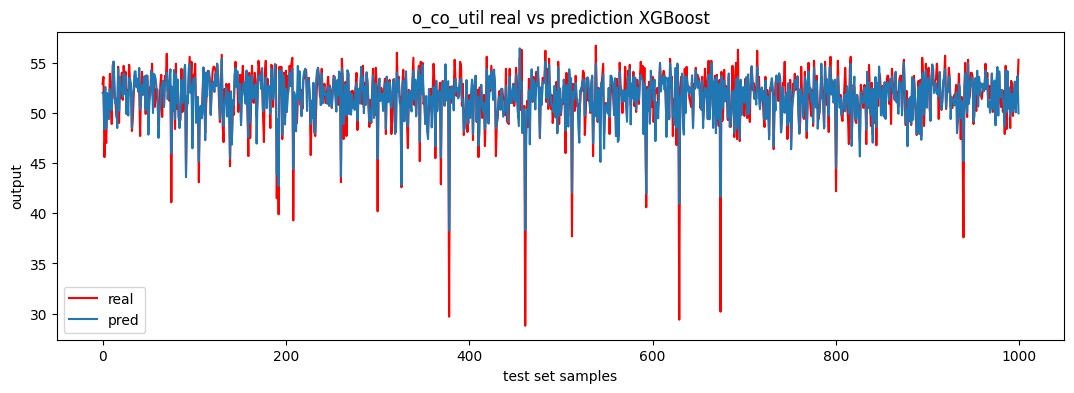

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


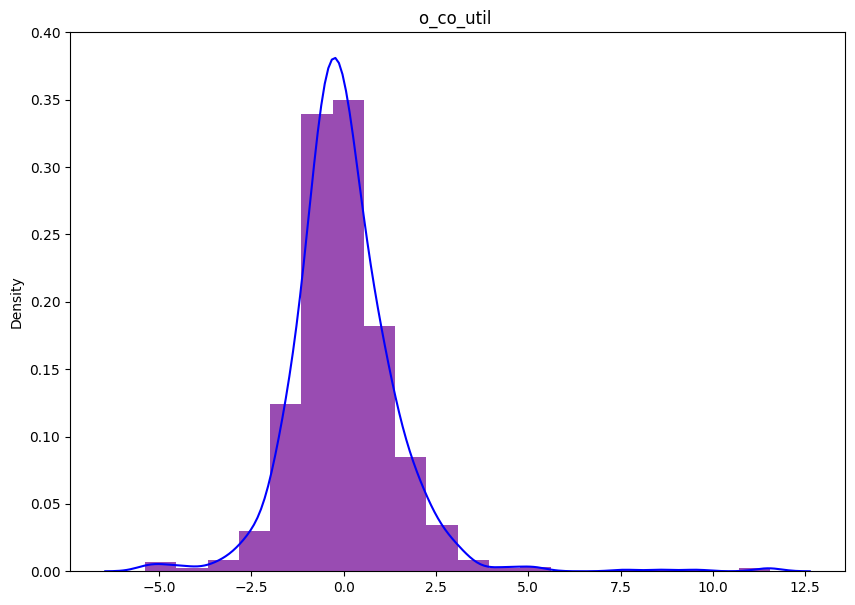

In [59]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


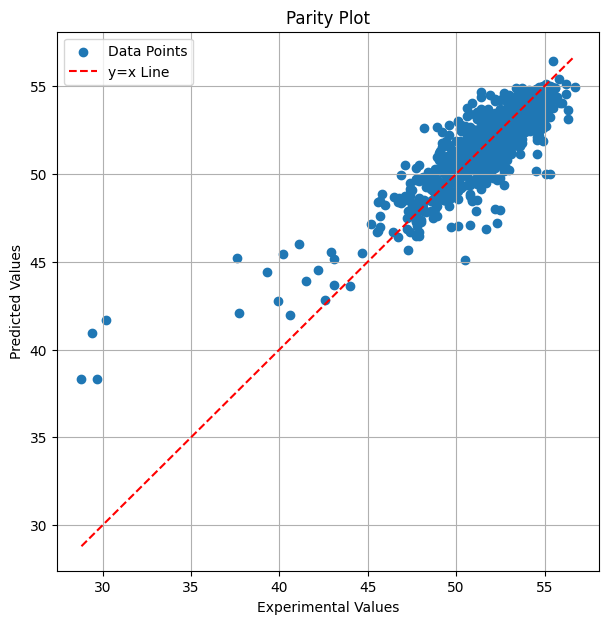

In [60]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## ONNX and XGboost


In [61]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [62]:


print(model)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, gamma=0, gpu_id=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, predictor=None, random_state=None,
             reg_alpha=None, reg_lambda=1, ...)


In [63]:

model.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [64]:

y_pred = model.predict(PDFshapingOBJ.X_test )


In [65]:

y_pred


array([52.000565, 51.90557 , 48.37835 , 52.593655, 48.473335, 51.98291 ,
       51.76053 , 49.38778 , 52.37283 , 51.767784, 50.277824, 53.556923,
       55.118526, 52.797848, 50.94952 , 51.42021 , 48.49707 , 54.364277,
       50.228954, 53.608425, 52.290108, 52.541275, 51.62315 , 53.928436,
       51.898537, 53.629   , 49.888405, 52.088394, 49.74295 , 53.473495,
       53.463646, 52.445126, 48.50136 , 51.849957, 52.4456  , 54.129192,
       54.15316 , 52.554806, 53.409855, 52.09886 , 54.487076, 50.309235,
       51.380558, 52.793003, 51.857624, 53.52251 , 53.67347 , 50.290573,
       53.7518  , 53.144886, 47.839035, 51.131523, 51.84009 , 54.23962 ,
       53.686985, 49.991287, 53.896103, 53.753742, 53.29695 , 52.3407  ,
       52.31313 , 47.513527, 50.07275 , 50.82661 , 52.530357, 52.78163 ,
       53.20241 , 50.58664 , 52.963776, 52.902023, 54.01858 , 51.367   ,
       52.933174, 53.383858, 54.35208 , 45.994766, 52.5692  , 50.2756  ,
       54.280247, 49.385715, 53.872715, 50.963215, 

In [66]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.7397374601413422

In [67]:

initial_types = [(
         'float_input', 
         FloatTensorType(     [ None, PDFshapingOBJ.X.shape[1] ]       )
)]


In [68]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

## target_opset=7

onnx_model = onnxmltools.convert_xgboost(model, initial_types=initial_types)

onnxmltools.utils.save_model(onnx_model, onnx_name_to_use)


In [69]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

# Setup runtime. This instantiates an ONNX inference session and loads the persisted model.
sess = rt.InferenceSession( onnx_name_to_use )


In [70]:

# Get model metadata to enable mapping of new input to the runtime model
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [71]:

input_name 


'float_input'

In [72]:

label_name


'variable'

In [73]:

# Create predictions. The inputs are the xtest values, and they are being casted as type float32.
pred_onnx = sess.run([label_name], {input_name: PDFshapingOBJ.X_test.astype(np.float32)})[0]


In [74]:

# Print first 10 predictions
print("Prediction:\n", pred_onnx[0:10])


Prediction:
 [[52.000565]
 [51.905563]
 [48.37834 ]
 [52.593643]
 [48.47334 ]
 [51.982914]
 [51.760536]
 [49.387787]
 [52.37283 ]
 [51.76777 ]]


In [75]:

test_count = 10
test_cases = PDFshapingOBJ.X_test[0:test_count]
local_pred = model.predict(test_cases)
print(f"Local predictions are: {local_pred}")


Local predictions are: [52.000565 51.90557  48.37835  52.593655 48.473335 51.98291  51.76053
 49.38778  52.37283  51.767784]


In [76]:

test_cases


array([[   0. ,    0. ,    0. ,  120. ,   24. ,  500. ,    0. , 1200. ,
         195. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [   0. ,   10. ,    0. ,   40. ,   24. ,  300. ,    0. , 1480. ,
         230. ,    5.7,    1. ,    0. ,    0. ,    0. ],
       [  10. ,    0. ,    0. ,    0. ,   30. ,    0. , 1200. , 1200. ,
         195. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [   0. ,  125. ,    0. ,    0. ,   21. ,    0. ,    0. , 1600. ,
         195. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,   80. ,   27. ,  300. ,    0. , 1200. ,
         230. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,  150. ,   30. ,  700. ,    0. , 1200. ,
         195. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,   90. ,   27. ,  300. ,    0. , 1448. ,
         195. ,   11.4,    7. ,    0. ,    0. ,    0. ],
       [   0. ,  125. ,    0. ,    0. ,   21. ,    0. ,    0. , 1200. ,
         230. ,    5.7,  


## ONNX, XGBoost, and SKlearn pipeline


In [77]:

update_registered_converter(
    XGBRegressor, 'XGBoostXGBRegressor',
    calculate_linear_regressor_output_shapes, 
    convert_xgboost
)


In [78]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)

pipe = Pipeline([
            ('xgb', model) 
])



pipe.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


Pipeline(steps=[('xgb',
                 XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
                              colsample_bylevel=1, colsample_bynode=1,
                              colsample_bytree=1, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              gamma=0, gpu_id=-1, grow_policy='depthwise',
                              importance_type=None, interaction_constraints='',
                              learning_rate=0.300000012, max_bin=256,
                              max_cat_to_onehot=4, max_delta_step=0,
                              max_depth=3, max_leaves=0, min_child_weight=1,
                              missing=nan, monotone_constraints='()',
                              n_estimators=100, n_jobs=0, num_parallel_tree=1,
                              predictor='auto', random_state=0, reg_alpha=0,
                              reg_lambda=1, ...))])

In [79]:

y_pred = pipe.predict(PDFshapingOBJ.X_test )


In [80]:

y_pred


array([52.000565, 51.90557 , 48.37835 , 52.593655, 48.473335, 51.98291 ,
       51.76053 , 49.38778 , 52.37283 , 51.767784, 50.277824, 53.556923,
       55.118526, 52.797848, 50.94952 , 51.42021 , 48.49707 , 54.364277,
       50.228954, 53.608425, 52.290108, 52.541275, 51.62315 , 53.928436,
       51.898537, 53.629   , 49.888405, 52.088394, 49.74295 , 53.473495,
       53.463646, 52.445126, 48.50136 , 51.849957, 52.4456  , 54.129192,
       54.15316 , 52.554806, 53.409855, 52.09886 , 54.487076, 50.309235,
       51.380558, 52.793003, 51.857624, 53.52251 , 53.67347 , 50.290573,
       53.7518  , 53.144886, 47.839035, 51.131523, 51.84009 , 54.23962 ,
       53.686985, 49.991287, 53.896103, 53.753742, 53.29695 , 52.3407  ,
       52.31313 , 47.513527, 50.07275 , 50.82661 , 52.530357, 52.78163 ,
       53.20241 , 50.58664 , 52.963776, 52.902023, 54.01858 , 51.367   ,
       52.933174, 53.383858, 54.35208 , 45.994766, 52.5692  , 50.2756  ,
       54.280247, 49.385715, 53.872715, 50.963215, 

In [81]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.7397374601413422

In [82]:

onnx_name_to_use = 'pipeline_xgboost_' + ONNX_name

model_onnx = convert_sklearn(
    pipe, 
    onnx_name_to_use,
    [ ('input', FloatTensorType([None, PDFshapingOBJ.X.shape[1]])) ],
    target_opset={'': 7, 'ai.onnx.ml': 1})


In [83]:

onnx_name_to_use = "ONNXmodels/pipeline_xgboost_" + ONNX_name + ".onnx"

with open(onnx_name_to_use, "wb") as f:
    f.write(model_onnx.SerializeToString())
    

In [84]:
onx = to_onnx(pipe, PDFshapingOBJ.X_test.astype(np.float32),
              target_opset={'': 7, 'ai.onnx.ml': 1})

sess = rt.InferenceSession(onx.SerializeToString())
pred_onx = sess.run(None, {"X": PDFshapingOBJ.X_test[:5].astype(np.float32)})
print("predict", pred_onx[0].ravel())



predict [52.000565 51.90557  48.37835  52.593655 48.473335]


In [85]:

input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [86]:
label_name 

'variable'

In [87]:
input_name 

'X'